In [36]:
import brainpy as bp
import brainpy.math as bm
import numpy as np
import matplotlib.pyplot as plt

In [55]:
import brainpy as bp
import brainpy.math as bm

from brainpy.dyn.neurons import GradNeuDyn
from brainpy.dyn import NeuDyn
from brainpy.initialize import ZeroInit, OneInit, Uniform, variable_, noise as init_noise
from brainpy import share
from brainpy.types import Shape, ArrayType
from brainpy.check import is_initializer
from brainpy import odeint, sdeint, JointEq
from typing import Union, Callable, Optional, Sequence, Any
from functools import partial

class Treves1993(GradNeuDyn):
    r"""
    Treves 1993 neuron model with adaptation current.

    **Model Description**

    The neuron model follows the equations described in Treves (1993), including a potassium
    current for adaptation in excitatory neurons.

    **Membrane Potential Dynamics**

    .. math::

        C \frac{dV}{dt} = -g_L (V - V_L) + I_K + I_{\text{ext}}

    where:

    - \( V \) is the membrane potential.
    - \( C \) is the membrane capacitance.
    - \( g_L \) is the leak conductance.
    - \( V_L \) is the leak reversal potential.
    - \( I_K \) is the potassium adaptation current.
    - \( I_{\text{ext}} \) is the external input current.

    **Potassium Current**

    .. math::

        I_K = -g_K (V - V_K)

    where:

    - \( g_K \) is the potassium conductance.
    - \( V_K \) is the potassium reversal potential.

    **Potassium Conductance Dynamics**

    .. math::

        \frac{d g_K}{dt} = -\frac{g_K}{\tau_K} + \Delta g_K \sum_k \delta(t - t_k)

    - \( \tau_K \) is the adaptation time constant.
    - \( \Delta g_K \) is the conductance increment upon each spike.
    - \( t_k \) are the spike times.

    **Spike Dynamics**

    - When \( V \geq V_{\text{th}} \), the neuron emits a spike.
    - The membrane potential is reset to \( V_{\text{rt}} \).
    - The neuron enters a refractory period of duration \( \tau_{\text{ref}} \).

    **Parameters**

    ============= =============== ======= ==========================================
    **Parameter** **Default**     **Unit** **Description**
    ------------- --------------- ------- ------------------------------------------
    C             250             pF      Membrane capacitance.
    g_L           16.7            nS      Leak conductance.
    V_L           -70.0           mV      Leak reversal potential.
    V_K           -85.0           mV      Potassium reversal potential.
    V_th          -50.0           mV      Spike threshold.
    V_rt          -60.0           mV      Reset potential.
    tau_ref       4.0             ms      Refractory period duration.
    tau_K         80.0            ms      Adaptation time constant.
    Delta_g_K     10.0            nS      Conductance increment upon spike.
    ============= =============== ======= ==========================================

    **Variables**

    =================== ================= ===================================================
    **Variable Name**   **Initial Value**  **Description**
    ------------------- ------------------ ---------------------------------------------------
    V                   V_initializer     Membrane potential.
    g_K                 g_K_initializer   Potassium conductance.
    spike               False             Spike indicator.
    t_last_spike        -1e8              Time of the last spike.
    =================== ================= ===================================================

    **Example Usage**

    .. code-block:: python

        import brainpy as bp

        # Define neuron parameters
        neuron = Treves1993(size=100, Delta_g_K=10.0)

        # Run the simulation
        runner = bp.DSRunner(neuron, monitors=['V', 'spike'])
        runner.run(100.0)

        # Plot results
        bp.visualize.line_plot(runner.mon.ts, runner.mon.V, show=True)

    """

    def __init__(
        self,
        size: Shape,
        sharding: Optional[Sequence[str]] = None,
        keep_size: bool = False,
        mode: Optional[bm.Mode] = None,
        name: Optional[str] = None,
        spk_fun: Callable = bm.surrogate.InvSquareGrad(),
        spk_dtype: Any = None,
        spk_reset: str = 'hard',
        detach_spk: bool = False,
        method: str = 'exp_auto',
        init_var: bool = True,
        scaling: Optional[bm.Scaling] = None,

        # neuron parameters
        C: Union[float, ArrayType, Callable] = 0.25,  # nF
        g_L: Union[float, ArrayType, Callable] = 16.7,  # nS
        V_L: Union[float, ArrayType, Callable] = -70.,  # mV
        V_K: Union[float, ArrayType, Callable] = -85.,  # mV
        V_th: Union[float, ArrayType, Callable] = -50.,  # mV
        V_rt: Union[float, ArrayType, Callable] = -60.,  # mV
        tau_ref: Union[float, ArrayType, Callable] = 4.,  # ms
        tau_K: Union[float, ArrayType, Callable] = 80.,  # ms
        Delta_g_K: Union[float, ArrayType, Callable] = 10.,  # nS

        V_initializer: Union[Callable, ArrayType] = ZeroInit(),
        g_K_initializer: Union[Callable, ArrayType] = ZeroInit(),

        # noise
        noise: Union[float, ArrayType, Callable] = None,
    ):
        super().__init__(size=size,
                         name=name,
                         keep_size=keep_size,
                         mode=mode,
                         sharding=sharding,
                         spk_fun=spk_fun,
                         detach_spk=detach_spk,
                         method=method,
                         spk_dtype=spk_dtype,
                         spk_reset=spk_reset,
                         scaling=scaling)

        # parameters
        self.C = self.init_param(C)
        self.g_L = self.init_param(g_L)
        self.V_L = self.init_param(V_L)
        self.V_K = self.init_param(V_K)
        self.V_th = self.init_param(V_th)
        self.V_rt = self.init_param(V_rt)
        self.tau_ref = self.init_param(tau_ref)
        self.tau_K = self.init_param(tau_K)
        self.Delta_g_K = self.init_param(Delta_g_K)

        # initializers
        self._V_initializer = is_initializer(V_initializer)
        self._g_K_initializer = is_initializer(g_K_initializer)

        # integral
        self.noise = init_noise(noise, self.varshape, num_vars=2)
        if self.noise is not None:
            self.integral = sdeint(method=self.method, f=self.derivative, g=self.noise)
        else:
            self.integral = odeint(method=method, f=self.derivative)

        # variables
        if init_var:
            self.reset_state(self.mode)

    def dV(self, V, t, g_K, I_ext):
        I_ext = self.sum_current_inputs(V, init=I_ext)
        I_K = - g_K * (V - self.V_K)
        dVdt = (- self.g_L * (V - self.V_L) + I_K + I_ext) / self.C
        return dVdt

    def dg_K(self, g_K, t):
        dg_Kdt = - g_K / self.tau_K
        return dg_Kdt

    @property
    def derivative(self):
        return JointEq([self.dV, self.dg_K])

    def reset_state(self, batch_size=None, **kwargs):
        self.V = self.init_variable(self._V_initializer, batch_size)
        self.g_K = self.init_variable(self._g_K_initializer, batch_size)
        self.spike = self.init_variable(partial(bm.zeros, dtype=self.spk_dtype), batch_size)
        self.t_last_spike = self.init_variable(bm.ones, batch_size)
        self.t_last_spike.fill_(-1e8)

    def update(self, I_ext=None):
        t = share.load('t')
        dt = share.load('dt')
        if I_ext is None:
            I_ext = 0.

        # integrate variables
        V, g_K = self.integral(self.V.value, self.g_K.value, t, I_ext, dt)
        V += self.sum_delta_inputs()

        # refractory period
        refractory = (t - self.t_last_spike) <= self.tau_ref
        V = bm.where(refractory, self.V.value, V)

        # spike
        if isinstance(self.mode, bm.TrainingMode):
            spike = self.spk_fun(V - self.V_th)
            spike_no_grad = stop_gradient(spike) if self.detach_spk else spike

            if self.spk_reset == 'soft':
                V -= (self.V_th - self.V_rt) * spike_no_grad
            elif self.spk_reset == 'hard':
                V += (self.V_rt - V) * spike_no_grad
            else:
                raise ValueError

            t_last_spike = stop_gradient(bm.where(spike_no_grad > 0., t, self.t_last_spike.value))
            refractory = stop_gradient(bm.logical_or(refractory, spike_no_grad > 0.).value)

            # Update g_K upon spike
            g_K += self.Delta_g_K * spike_no_grad

        else:
            spike = V >= self.V_th
            V = bm.where(spike, self.V_rt, V)
            t_last_spike = bm.where(spike, t, self.t_last_spike.value)

            # Update g_K upon spike
            g_K = bm.where(spike, g_K + self.Delta_g_K, g_K)

        # update variables
        self.V.value = V
        self.g_K.value = g_K
        self.spike.value = spike
        self.t_last_spike.value = t_last_spike

        return spike


Predict 40000 steps: : 100%|██████████| 40000/40000 [00:00<00:00, 83380.71it/s]


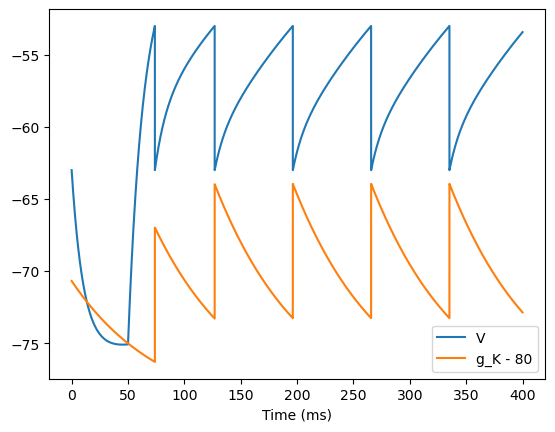

In [73]:
# Reproduce figure 1 from Treves 1993
neu = Treves1993(
    size=1,
    C=375,            # pF
    g_L=25.0,         # nS
    V_L=-73.0,        # mV
    V_K=-85.0,        # mV
    V_th=-53.0,       # mV
    V_rt=-63.0,       # mV
    tau_ref=0.,       # ns
    tau_K=80.0,       # ms
    Delta_g_K=9.315,  # nS
)


runner = bp.DSRunner(neu, monitors=['V', 'g_K'], dt=0.01)
inputs = bp.inputs.section_input([0., 750.], [50., 350.], dt=runner.dt)
runner.run(inputs=inputs)

bp.visualize.line_plot(runner.mon['ts'], runner.mon['V'], legend='V')
bp.visualize.line_plot(runner.mon['ts'], runner.mon['g_K']-80, legend='g_K - 80', show=True)